In [1]:
__nbid__ = '0074'
__author__ = 'Stephanie Juneau <stephanie.juneau@noirlab.edu>, Ragadeepika Pucha <raga.pucha@utah.edu>, Alice Jacques <alice.jacques@noirlab.edu>, Benjamin Weaver <benjamin.weaver@noirlab.edu>'
__version__ = '20250723' # yyyymmdd
__datasets__ = ['desi_dr1'] 
__keywords__ = ['sparcl', 'spectra', 'database']

# Introduction to DESI First Data Release (DR1) at the Astro Data Lab

*Stéphanie Juneau (NOIRLab), Ragadeepika Pucha (U. Utah), Alice Jacques (NOIRLab), Benjamin Weaver (NOIRLab), and the Astro Data Lab Team, with contributions from Anthony Kremin (LBL), Jaime E. Forero Romero (U. de los Andes), Stephen Bailey (LBL), and the DESI Collaboration*

### Table of Contents

* [Goals & summary](#goals)
* [Disclaimer & attribution](#attribution)
* [Imports](#import)
* [DESI DR1 database](#desi_dr1)
* [Accessing DESI targets](#desi_target_access)
    * [Selecting sources based on targeting information](#target_info)
    * [Selecting sources in a region of the sky](#hpx_sel)
* [Accessing and plotting the spectra of a given object](#spectra_access)
* [Objects with multiple coadded spectra](#multiple_spectra)
* [References](#ref)

<a class="anchor" id="goals"></a>
# Goals

In this notebook, we will explore the DESI First Data Release (DESI DR1) at Astro Data Lab. Namely, we show how to access the redshift catalog from the Data Lab database, how to separate objects based on the DESI targeting information, how to access all the available spectra for a given object using [SPARCL](https://astrosparcl.datalab.noirlab.edu/sparc/) (SPectra Analysis and Retrievable Catalog Lab), and how to plot the "best" spectrum. Finally, we show how to query objects with more than one coadded spectrum in the Main DESI survey.

# Summary

The Dark Energy Spectroscopic Instrument (DESI) is a 5000-fiber multi-object spectrograph built by the Department of Energy (DOE). It is installed on the 4-meter Mayall telescope on Kitt Peak, AZ and used to conduct a survey spanning ~14,000 deg$^2$ over 5 years (2021-2026). The DESI First Data Release (DR1) consists of spectra of 18 million unique objects observed during the first 13 months of the Main DESI survey ("Year 1"). It further includes a reprocessing of the same commissioning data and survey validation (SV) data that were previously included in DEDI EDR. This includes SV1, SV2, and SV3 (the One-Percent survey). The name of the database with DESI DR1 catalog tables is `desi_dr1`. More information about DESI DR1 is available both from the [DESI Data Documentation website](https://data.desi.lbl.gov/doc/) and from the [Astro Data Lab DESI webpage](https://datalab.noirlab.edu/desi/).

In this notebook, we show how to access the different tables associated with this database to get targeting and redshift information regarding the targets and then use the SPARCL spectral database to retrieve the spectra. We focus our examples on the Main survey, but they could be extended to the SV data by querying for the SV-specific columns and adapting the code accordingly.

<a class="anchor" id="attribution"></a>
# Disclaimer & attribution

Disclaimers
-----------
Note that using the Astro Data Lab constitutes your agreement with our minimal [Disclaimers](https://datalab.noirlab.edu/disclaimers.php).

Acknowledgments
---------------
If you use **Astro Data Lab** in your published research, please include the text in your paper's Acknowledgments section:

_This research uses services or data provided by the Astro Data Lab, which is part of the Community Science and Data Center (CSDC) Program of NSF NOIRLab. NOIRLab is operated by the Association of Universities for Research in Astronomy (AURA), Inc. under a cooperative agreement with the U.S. National Science Foundation._

If you use **SPARCL jointly with the Astro Data Lab platform** (via JupyterLab, command-line, or web interface) in your published research, please include this text below in your paper's Acknowledgments section:

_This research uses services or data provided by the SPectra Analysis and Retrievable Catalog Lab (SPARCL) and the Astro Data Lab, which are both part of the Community Science and Data Center (CSDC) Program of NSF NOIRLab. NOIRLab is operated by the Association of Universities for Research in Astronomy (AURA), Inc. under a cooperative agreement with the U.S. National Science Foundation._

In either case **please cite the following papers**:

* Data Lab concept paper: Fitzpatrick et al., "The NOAO Data Laboratory: a conceptual overview", SPIE, 9149, 2014, https://doi.org/10.1117/12.2057445

* Astro Data Lab overview: Nikutta et al., "Data Lab - A Community Science Platform", Astronomy and Computing, 33, 2020, https://doi.org/10.1016/j.ascom.2020.100411

If you are referring to the Data Lab JupyterLab / Jupyter Notebooks, cite:

* Juneau et al., "Jupyter-Enabled Astrophysical Analysis Using Data-Proximate Computing Platforms", CiSE, 23, 15, 2021, https://doi.org/10.1109/MCSE.2021.3057097

If publishing in a AAS journal, also add the keyword: `\facility{Astro Data Lab}`

And if you are using SPARCL, please also add `\software{SPARCL (Juneau et al. 2024)}` and cite:

* Juneau et al., "SPARCL: SPectra Analysis and Retrievable Catalog Lab", Conference Proceedings for ADASS XXXIII, 2024
https://doi.org/10.48550/arXiv.2401.05576

The NOIRLab Library maintains [lists of proper acknowledgments](https://noirlab.edu/science/about/scientific-acknowledgments) to use when publishing papers using the Lab's facilities, data, or services.

For this notebook specifically, please acknowledge:
* DESI data license and acknowledgments: https://data.desi.lbl.gov/doc/acknowledgments/
* Astro Data Lab: https://datalab.noirlab.edu/acknowledgments.php
* SPARCL: https://astrosparcl.datalab.noirlab.edu/sparc/acknowledgments

<a class="anchor" id="import"></a>
# Imports

In [2]:
# import some helpful python packages 
import numpy as np
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
import matplotlib 
import matplotlib.pyplot as plt

# DESI targeting masks 
from desitarget import targetmask            # For Main survey
from desitarget.sv1 import sv1_targetmask    # For SV1
from desitarget.sv2 import sv2_targetmask    # For SV2
from desitarget.sv3 import sv3_targetmask    # For SV3

# DataLab related modules
from sparcl.client import SparclClient
from dl import queryClient as qc, authClient as ac
from getpass import getpass

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


In [3]:
# Authentication
# Much of the functionality of spectrum services can be accessed without explicitly logging into Data Lab (the services then uses an anonymous login). 
# But some capabilities, for instance saving the results of your queries to your virtual storage space, require a login (i.e., you will need a registered user account).

# If you need to log in to Data Lab, uncomment the 'ac.login()' command and respond according to your prompts. 
# If you have previously logged into Data Lab, this cell will simply print your active user name.

# token = ac.login(input("Enter user name: (+ENTER) "), getpass("Enter password: (+ENTER) "))
# ac.whoAmI()

In [4]:
# Making the matplotlib plots look nicer

settings = {
    'font.size':16,
    'axes.linewidth':2.0,
    'xtick.major.size':6.0,
    'xtick.minor.size':4.0,
    'xtick.major.width':2.0,
    'xtick.minor.width':1.5,
    'xtick.direction':'in', 
    'xtick.minor.visible':True,
    'xtick.top':True,
    'ytick.major.size':6.0,
    'ytick.minor.size':4.0,
    'ytick.major.width':2.0,
    'ytick.minor.width':1.5,
    'ytick.direction':'in', 
    'ytick.minor.visible':True,
    'ytick.right':True
}

plt.rcParams.update(**settings)

In [5]:
# Load SPARCLClient
client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


<a class="anchor" id="desi_dr1"></a>
# DESI DR1 database

The `desi_dr1` database schema at Data Lab consists of several tables associated with the targets.

In [6]:
print(qc.schema('desi_dr1'))


Schema: desi_dr1

      Table Name   Description
      ----------   -----------
          agngal   Value-Added Catalog of DESI DR1 galaxies and quasars with 
                   spectral and infrared classification diagnostics (17,995,5
                   99 rows)
           emfit   Emission-Line flux and width measurements for low-redshift
                   (z <= 0.45) sources in DR1 (7,378,347 rows)
        exposure   Summary quantities for every DESI exposure (9,176 rows)
     fiberassign   Quantities obtained when a DESI target is assigned to a fi
                   ber (25,061,082 rows)
           frame   Summary quantities for each petal of the DESI instrument i
                   n a given exposure; in normal operation there are ten fram
                   es for every exposure (269,960 rows)
             mws   Milky Way Survey Value-Added Catalog (6,372,607 rows)
      photometry   Photometric quantities from LS DR9 for every TARGETID (76,
                   001,458 rows)
    

We will focus on the `zpix` table in this notebook. This is the main redshift catalog from the DESI survey. It contains the redshift information from the coadded-spectra, based on the healpix of the objects. It also contains the targeting information of the different sources.

We look at the available columns in this table below.

In [7]:
# Columns in the zpix table
print(qc.schema('desi_dr1.zpix'))


Schema: desi_dr1
 Table: zpix

     Column Name   Description
     -----------   -----------
     tsnr2_lrg_b   LRG B template (S/N)^2
 tsnr2_gpbdark_r   GPBDARK R template (S/N)^2
     tsnr2_elg_r   ELG R template (S/N)^2
tsnr2_gpbbright_r   GPBBRIGHT R template (S/N)^2
     tsnr2_lya_r   LYA R template (S/N)^2
               z   Redshift measured by Redrock
            zerr   Redshift error from Redrock
            chi2   Best fit chi squared
         coeff_0   Redrock template coefficients
         coeff_1   Redrock template coefficients
         coeff_2   Redrock template coefficients
         coeff_3   Redrock template coefficients
         coeff_4   Redrock template coefficients
         coeff_5   Redrock template coefficients
         coeff_6   Redrock template coefficients
         coeff_7   Redrock template coefficients
         coeff_8   Redrock template coefficients
         coeff_9   Redrock template coefficients
       deltachi2   Delta-chi-squared for template fit from R

<a class="anchor" id="desi_target_access"></a>
# Accessing DESI targets

The DESI spectra are uniquely identified by three quantities:

* **targetid**: unique identifier for a given target
* **survey**: SURVEY that the target was observed in. This can be _main_ (for the Main survey) or _cmx_, _special_, _sv1_, _sv2_, or _sv3_.
* **program**: FIBER ASSIGNMENT PROGRAM. This is the planned observing conditions for the target. It can be _dark_ or _bright_ or _backup_. In case of cmx and sv1, there is _other_ as well.
    
The different spectra observations of individual targets are coadded within each survey and program. Therefore, some targets may have multiple coadded spectra and each one is associated with a given `targetid`, `survey`, and `program`. The "best" spectrum for a given object is given by the `zcat_primary` column. More information about the data model of the redshift catalogs is available [here](https://desidatamodel.readthedocs.io/en/latest/DESI_SPECTRO_REDUX/SPECPROD/zcatalog/zpix-SURVEY-PROGRAM.html#).

For this query, we will select from the Main survey (`survey='main'`). Because the zpix table is large with 23 million rows, we will only get 10% randomly distributed on the sky, by making a cut on `random_id` (Random ID in the range 0.0 => 100.0).

In [8]:
# Write a query to select the primary spectrum in the Main survey for 10% of the sample
# (see detailed information below)
query = """
        SELECT zp.targetid, zp.survey, zp.program, zp.desi_target, 
               zp.mean_fiber_ra, zp.mean_fiber_dec, 
               zp.z, zp.zwarn, zp.spectype
        FROM desi_dr1.zpix AS zp
        WHERE (zp.survey='main') AND zp.main_primary AND (zp.random_id BETWEEN 0. AND 10.)
        """ 

# Information about the query
# Selected columns --
#   targetid, survey, program -- unique identifiers for a given spectrum
#   desi_target -- encodes main survey's desi targeting information - explained in detail below
#   mean_fiber_ra, mean_fiber_dec -- coordinates where fiber was placed
#   z -- spectroscopic redshift of the target
#   zwarn -- encoded information regarding the redshift (zwarn = 0 is good)
#   spectype -- Spectral type of the target: STAR | GALAXY | QSO
# Constraints (WHERE statement) --
#   survey: selecting main survey only
#   main_primary: keeping only the best spectrum in Main (removes possible multiples)
#   random_id: selects a slice of 10% of the sample (0-10 out of 100)

In [9]:
print(query)


        SELECT zp.targetid, zp.survey, zp.program, zp.desi_target, 
               zp.mean_fiber_ra, zp.mean_fiber_dec, 
               zp.z, zp.zwarn, zp.spectype
        FROM desi_dr1.zpix AS zp
        WHERE (zp.survey='main') AND zp.main_primary AND (zp.random_id BETWEEN 0. AND 10.)
        


In [12]:
zpix_cat = qc.query(sql = query, fmt = 'table')

In [14]:
print(f"The resulting table has {len(zpix_cat)} rows, and comprises 10% of the sample size")
zpix_cat[0:10]

The resulting table has 2063506 rows, and comprises 10% of the sample size


targetid,survey,program,desi_target,mean_fiber_ra,mean_fiber_dec,z,zwarn,spectype
int64,str4,str6,int64,float64,float64,float64,int64,str6
39628129664239940,main,dark,65537,234.7166322469532,14.27766943485698,0.6129316573380434,0,GALAXY
39627660451645263,main,dark,917542,146.505791478883,-5.361541128676229,2.274544489801376,0,QSO
39632981819656750,main,dark,1028,250.8452391416031,34.96682360092108,3.026060340852765,0,QSO
39628310233219875,main,dark,65537,36.75448828509968,22.26330131482691,0.5896048730671053,0,GALAXY
39627715627715582,main,dark,655394,201.3880181513268,-2.939781972005333,1.541882595749106,0,GALAXY
39627799941614019,main,dark,1179778,186.8737773160079,0.5546182919671089,0.8982194887853038,0,GALAXY
39632950081356773,main,bright,1152921504606847233,127.4506470555749,33.44109003111979,0.4250103198838487,0,GALAXY
39627815271793810,main,bright,1152921504606846976,20.53013410414536,1.19640904500459,0.3696993296087152,0,GALAXY
39633346392754903,main,bright,1152921504606846976,255.0945985319847,56.84068401512603,0.09237737555381197,0,GALAXY


In [15]:
# Check that rows have unique TARGETIDs (only one PRIMARY spectrum per object)
Ntot = len(zpix_cat)
print(f"Total N(rows) : {Ntot}")
print(f"N(rows) with unique TARGETIDs : {len(np.unique(zpix_cat['targetid']))}")

Total N(rows) : 2063506
N(rows) with unique TARGETIDs : 2063506


In [268]:
# Check the spectral types
spectypes = np.unique(zpix_cat['spectype'])

for spectype in spectypes:
    Nspectype = len(zpix_cat[zpix_cat['spectype']==spectype])
    # Percentage rounded to 1 decimal
    percent = np.round(Nspectype/Ntot*100, 1)
    print(f"SPECTYPE={spectype} includes N={Nspectype} ({percent}%)")

SPECTYPE=GALAXY includes N=1479652 (71.7%)
SPECTYPE=QSO includes N=165098 (8.0%)
SPECTYPE=STAR includes N=418756 (20.3%)


## Selecting sources based on targeting information

DESI targets are divided into five main classes:
* MWS: Milky Way Survey - This survey probes "stars" in the Milky Way.
* BGS: Bright Galaxy Survey - This survey probes the bright galaxies in the nearby universe.
* LRG: Luminous Red Galaxies
* ELG: Emission Line Galaxies
* QSO: Quasars

[Myers et al. 2023](https://ui.adsabs.harvard.edu/abs/2023AJ....165...50M/abstract) describes the target selection and information in more detail.

The `*DESI_TARGET` columns encode the information related to which class the target belongs to. Note that some sources can be part of different classes. <br/>
In this section, we show how to select sources based on their targeting information.

The targetmasks contain the bit information regarding the different targeting classes. <br/>
Apart from these main classes, there are targets that are part of secondary-fiber proposal programs. These targets are encoded under `SECONDARY PROGRAM`.

In [17]:
# Targeting bits are coded in the stargetmask.desi_mask
targetmask.desi_mask

desi_mask:
  - [LRG,              0, "LRG", {'obsconditions': 'DARK', 'priorities': {'UNOBS': 3200, 'MORE_ZGOOD': 2, 'MORE_ZWARN': 2, 'DONE': 2, 'OBS': 1, 'DONOTOBSERVE': 0, 'MORE_MIDZQSO': 0, 'LY_1B_ELG': 1, 'MORE_NOB1': 1, 'MORE_NOB2': 1, 'MORE_NOB3': 1}, 'numobs': 2}]
  - [ELG,              1, "ELG", {'obsconditions': 'DARK', 'priorities': {'UNOBS': 3000, 'LY_1B_ELG': 3340, 'MORE_ZGOOD': 2, 'MORE_ZWARN': 2, 'DONE': 2, 'OBS': 1, 'DONOTOBSERVE': 0, 'MORE_MIDZQSO': 0, 'MORE_NOB1': 1, 'MORE_NOB2': 1, 'MORE_NOB3': 1}, 'numobs': 2}]
  - [QSO,              2, "QSO", {'obsconditions': 'DARK', 'priorities': {'UNOBS': 3400, 'MORE_ZGOOD': 3350, 'MORE_ZWARN': 3300, 'MORE_MIDZQSO': 100, 'DONE': 2, 'OBS': 1, 'DONOTOBSERVE': 0, 'LY_1B_ELG': 1, 'MORE_NOB1': 1, 'MORE_NOB2': 1, 'MORE_NOB3': 1}, 'numobs': 4}]
  - [LGE,              3, "LRG for DESI extension", {'obsconditions': 'DARK1B', 'priorities': {'UNOBS': 3210, 'MORE_ZGOOD': 2, 'MORE_ZWARN': 2, 'DONE': 2, 'OBS': 1, 'DONOTOBSERVE': 0, 'MORE_MIDZQ

In [18]:
# A few example bitmask values

print(targetmask.desi_mask.mask("STD_FAINT"), targetmask.desi_mask.mask("STD_BRIGHT"), targetmask.desi_mask.mask("STD_FAINT|STD_BRIGHT"))

8589934592 34359738368 42949672960


In [63]:
# Targeting information about the DESI targeting is stored in the desi_target column for the Main survey
#   - targetmask.desi_mask corresponds to DESI_TARGET
# NOTE: There are different columns for the SV surveys (not used here but necessary to combine SV and Main data):
#  - sv1_targetmask.desi_mask corresponds to SV1_DESI_TARGET
#  - sv2_targetmask.desi_mask corresponds to SV2_DESI_TARGET
#  - sv3_targetmask.desi_mask corresponds to SV3_DESI_TARGET

desi_tgt = zpix_cat['desi_target']

# DESI Bitmasks
desi_mask = targetmask.desi_mask

['LRG', 'ELG', 'QSO', 'LGE', 'QSO_HIZ', 'ELG_LOP', 'ELG_HIP', 'ELG_VLO', 'LRG_NORTH', 'ELG_NORTH', 'QSO_NORTH', 'ELG_LOP_NORTH', 'ELG_VLO_NORTH', 'LGE_NORTH', 'LRG_SOUTH', 'ELG_SOUTH', 'QSO_SOUTH', 'ELG_LOP_SOUTH', 'ELG_VLO_SOUTH', 'LGE_SOUTH', 'SKY', 'STD_FAINT', 'STD_WD', 'STD_BRIGHT', 'BAD_SKY', 'SUPP_SKY', 'NO_TARGET', 'BRIGHT_OBJECT', 'IN_BRIGHT_OBJECT', 'NEAR_BRIGHT_OBJECT', 'BGS_ANY', 'MWS_ANY', 'SCND_ANY']


In [20]:
# Selecting based on target class

is_bgs = (desi_tgt & desi_mask['BGS_ANY'] != 0)
is_lrg = (desi_tgt & desi_mask['LRG'] != 0)
is_elg = (desi_tgt & desi_mask['ELG'] != 0)
is_qso = (desi_tgt & desi_mask['QSO'] != 0)
is_mws = (desi_tgt & desi_mask['MWS_ANY'] != 0)
is_scnd = (desi_tgt & desi_mask['SCND_ANY'] != 0)

In [21]:
# Number of sources of each target type
n_bgs = len(zpix_cat[is_bgs])
n_lrg = len(zpix_cat[is_lrg])
n_elg = len(zpix_cat[is_elg])
n_qso = len(zpix_cat[is_qso])
n_mws = len(zpix_cat[is_mws])
n_scnd = len(zpix_cat[is_scnd])

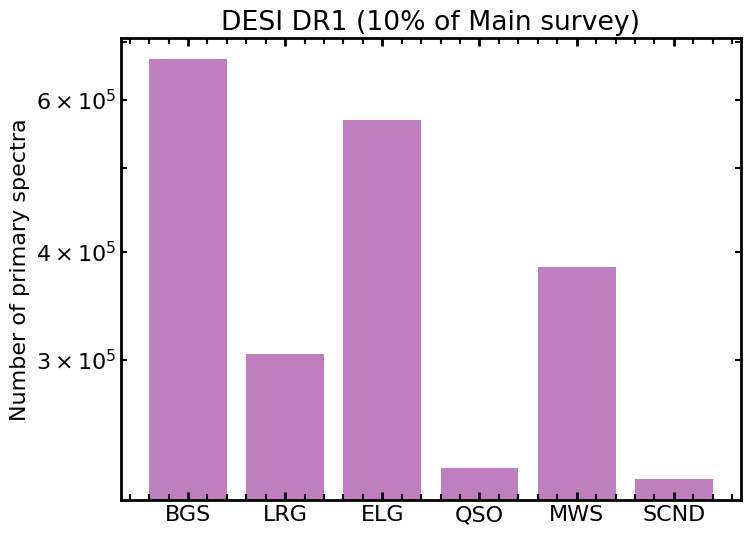

In [22]:
# Let us look at the numbers visually - 

plt.figure(figsize = (8,6))

targets = ['BGS', 'LRG', 'ELG', 'QSO', 'MWS', 'SCND']
numbers = [n_bgs, n_lrg, n_elg, n_qso, n_mws, n_scnd]

plt.bar(targets, numbers, color = 'purple', alpha = 0.5)
plt.ylabel('Number of primary spectra')
plt.yscale('log')
plt.title('DESI DR1 (10% of Main survey)');

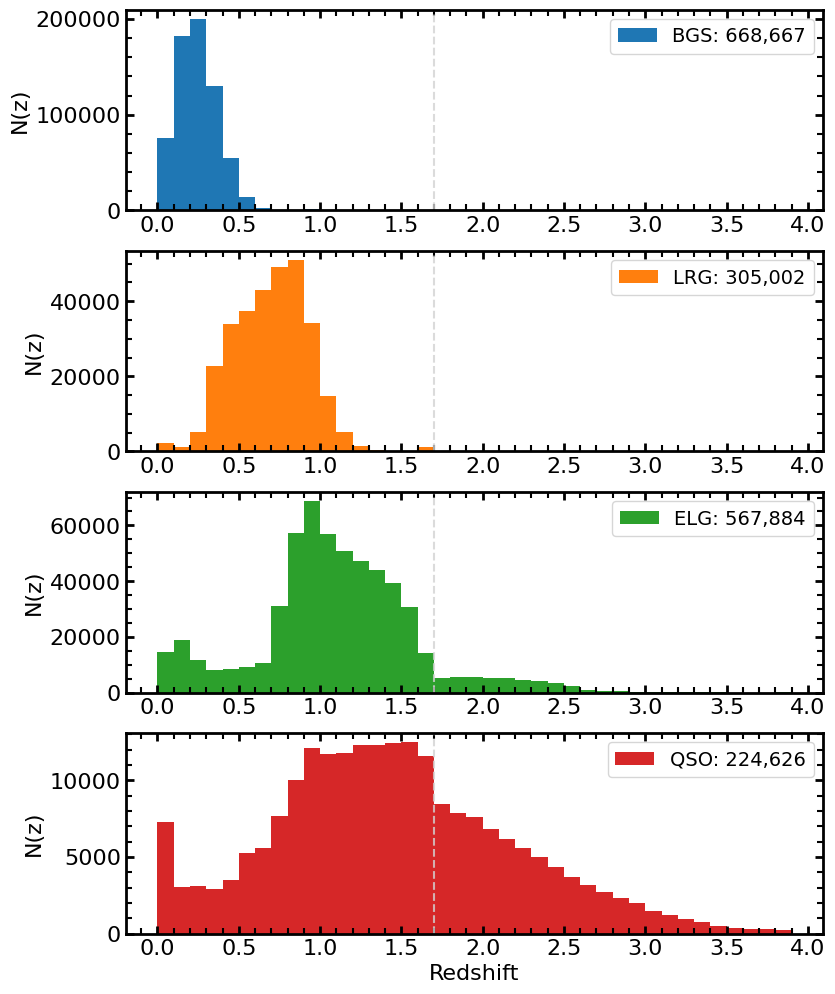

In [23]:
# Now let us look at the distribution of redshifts -

fig, axs = plt.subplots(4, 1, figsize=(9, 12))

# Define the redshift bins for the histograms
bins = np.arange(0, 4, 0.1)

# Will iterate over these 4 target classes
targets = [is_bgs, is_lrg, is_elg, is_qso]
colors = ['C0', 'C1', 'C2', 'C3']
labels = [f'BGS: {n_bgs:,}', f'LRG: {n_lrg:,}', f'ELG: {n_elg:,}', f'QSO: {n_qso:,}']

for i, target in enumerate(targets):
    axs[i].hist(zpix_cat['z'][target], color=colors[i], bins=bins, label=labels[i])
    axs[i].legend(fontsize=14)
    axs[i].set_ylabel("N(z)")

    # Vertical line at the limit for GALAXY type
    axs[i].axvline(1.7, ls='--', color='lightgrey', alpha=0.8)

# Add x-label on the last panel
axs[3].set_xlabel("Redshift");

### Other masks

`desi_mask` consists of the uppermost level targeting information in DESI. However, there are sub-classes of targets. <br/>
For example, BGS have different target masks depending on the selection criterion. Each of the different secondary target proposals have their own masks. They can be selected in a similar way as above, but with the respective columns (like `BGS_TARGET` or `SCND_TARGET`) in the `target` table. More information about Bitmasks in DESI is available [here](https://desidatamodel.readthedocs.io/en/latest/bitmasks.html).

In [24]:
# BGS Target Masks
targetmask.bgs_mask.names()

['BGS_FAINT',
 'BGS_BRIGHT',
 'BGS_WISE',
 'BGS_FAINT_HIP',
 'BGS_FAINT_NORTH',
 'BGS_BRIGHT_NORTH',
 'BGS_WISE_NORTH',
 'BGS_FAINT_SOUTH',
 'BGS_BRIGHT_SOUTH',
 'BGS_WISE_SOUTH']

In [25]:
# Secondary Target Masks
targetmask.scnd_mask.names()

['VETO',
 'UDG',
 'FIRST_MALS',
 'QSO_RED',
 'MWS_CLUS_GAL_DEEP',
 'LOW_MASS_AGN',
 'FAINT_HPM',
 'LOW_Z_TIER1',
 'LOW_Z_TIER2',
 'LOW_Z_TIER3',
 'BHB',
 'SPCV',
 'DC3R2_GAMA',
 'PSF_OUT_BRIGHT',
 'PSF_OUT_DARK',
 'HPM_SOUM',
 'SN_HOSTS',
 'GAL_CLUS_BCG',
 'GAL_CLUS_2ND',
 'GAL_CLUS_SAT',
 'MWS_FAINT_BLUE',
 'MWS_FAINT_RED',
 'STRONG_LENS',
 'WISE_VAR_QSO',
 'Z5_QSO',
 'MWS_RR_LYRAE',
 'MWS_MAIN_CLUSTER_SV',
 'BRIGHT_HPM',
 'WD_BINARIES_BRIGHT',
 'WD_BINARIES_DARK',
 'PV_BRIGHT_HIGH',
 'PV_BRIGHT_MEDIUM',
 'PV_BRIGHT_LOW',
 'PV_DARK_HIGH',
 'PV_DARK_MEDIUM',
 'PV_DARK_LOW',
 'GC_BRIGHT',
 'GC_DARK',
 'DWF_BRIGHT_HI',
 'DWF_BRIGHT_LO',
 'DWF_DARK_HI',
 'DWF_DARK_LO',
 'BRIGHT_TOO_LOP',
 'BRIGHT_TOO_HIP',
 'DARK_TOO_LOP',
 'DARK_TOO_HIP']

<a class="anchor" id="hpx_sel"></a>
## Selecting sources in a region of the sky

The targets are divided into different healpix regions on the sky. Here we select all the targets in a given healpix region.  
We also overplot the `Milky Way Survey` targets in this region.

In [29]:
#not sure about this, TO GET RA, DEC OF A SKY PIXEL: can just use tsel['mean_fiber_ra']
"""import healpy as hp

nside = 64
hpx = 26279

# Get the center of the pixel in RA, Dec (degrees)
ra, dec = hp.pix2ang(nside, hpx, nest=True, lonlat=True)
print(f"Center: RA = {ra:.4f} deg, Dec = {dec:.4f} deg")

# Pixel size
area_sqdeg = hp.nside2pixarea(nside, degrees=True)
resol_arcmin = hp.nside2resol(nside, arcmin=True)
print(f"Pixel area: {area_sqdeg:.4f} sq deg  (~{resol_arcmin:.2f} arcmin on a side)")""";

In [30]:
hpx = 26279      

# Write query to select this given healpix (detailed information below)
query = f'''SELECT zp.targetid, zp.survey, zp.program, zp.desi_target,
                   zp.z, zp.zwarn, zp.spectype, 
                   zp.mean_fiber_ra, zp.mean_fiber_dec 
            FROM desi_dr1.zpix AS zp
            WHERE (healpix={hpx} AND survey='main' AND main_primary)'''

# Information about the query
# 
# Selected columns:
#   targetid, survey, program -- unique identifiers for a given spectrum
#   desi_target -- encodeds main survey's desi targeting information
#   z -- spectroscopic redshift of the target
#   zwarn -- encoded information regarding the redshift (zwarn = 0 is good)
#   spectype -- Spectral type of the target: STAR | GALAXY | QSO
#   mean_fiber_ra, mean_fiber_dec -- coordinates where fiber was placed
# Constraints (WHERE statement):
#   healpix: select a specific one
#   survey: keep only the Main survey
#   main_primary: keep the best spectrum in the Main survey (in case there are duplicates)

In [31]:
tsel = qc.query(sql = query, fmt = 'table')

In [33]:
# Selecting MWS sources in this regions
is_mws = (tsel['desi_target'] & targetmask.desi_mask['MWS_ANY'] != 0)

In [38]:
is_bgs = (tsel['desi_target'] & targetmask.desi_mask['BGS_ANY'] != 0)

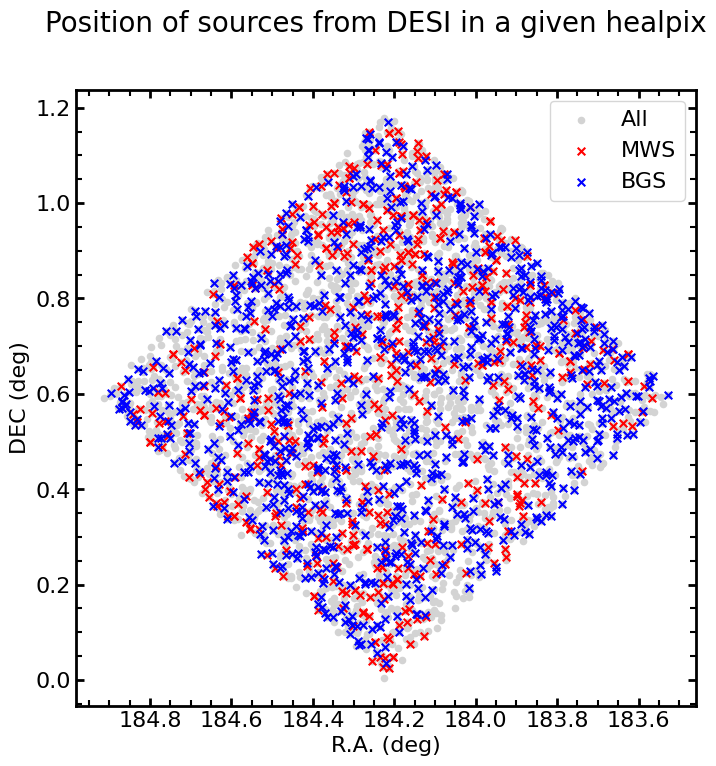

In [41]:
plt.figure(figsize = (8, 8))

plt.suptitle('Position of sources from DESI in a given healpix', fontsize = 20)
plt.scatter(tsel['mean_fiber_ra'], tsel['mean_fiber_dec'], color = 'lightgrey', s = 20, label = 'All')
plt.scatter(tsel['mean_fiber_ra'][is_mws], tsel['mean_fiber_dec'][is_mws], color = 'r', s = 30, marker = 'x', label = 'MWS')

plt.scatter(tsel['mean_fiber_ra'][is_bgs], tsel['mean_fiber_dec'][is_bgs], color = 'b', s = 30, marker = 'x', label = 'BGS')
plt.xlabel('R.A. (deg)')
plt.ylabel('DEC (deg)')
# RA increases toward the left (East)
plt.gca().invert_xaxis()
plt.legend();

<a class="anchor" id="spectra_access"></a>
# Accessing and plotting the spectra of a given object

Finally, we show how to access all the available healpix-coadded spectra of a given object. We also show how to select the "best" spectrum.  
We use SPARCL, which is a fast spectral access service at Data Lab.  
Detailed ways to use SPARCL are available in this [tutorial notebook](https://github.com/astro-datalab/notebooks-latest/blob/master/04_HowTos/SPARCL/How_to_use_SPARCL.ipynb).

In [532]:
# Select objects with nspec > 5
#query = '''SELECT zp.targetid, zp.survey, zp.program, zp.desi_target, zp.z, zp.zwarn, zp.coadd_fiberstatus, 
#                  zp.mean_fiber_ra, zp.mean_fiber_dec, zp.zcat_primary, zp.zcat_nspec, zp.tsnr2_lrg, zp.spectype
#           FROM desi_dr1.zpix  AS zp
#           WHERE zcat_nspec>1
#        '''

#tsel = qc.query(sql=query, fmt='table')

In [564]:
# Select objects with nspec > 5
query = '''SELECT zp.targetid, zp.survey, zp.program, zp.desi_target, zp.z, zp.zwarn, zp.coadd_fiberstatus, 
                  zp.mean_fiber_ra, zp.mean_fiber_dec, zp.zcat_primary, zp.zcat_nspec, zp.tsnr2_lrg, zp.spectype
           FROM desi_dr1.zpix  AS zp
           WHERE (zp.survey='main') AND zp.main_primary AND (zp.random_id BETWEEN 0. AND 10.)
           LIMIT 1000
        '''



tsel = qc.query(sql=query, fmt='table')
len(tsel)

1000

In [565]:
is_bgs = (tsel['desi_target'] & desi_mask['BGS_ANY']) != 0
tsel_bgs = tsel[is_bgs]

#is_lrg = (desi_tgt & desi_mask['LRG'] != 0)
#is_elg = (desi_tgt & desi_mask['ELG'] != 0)
#is_qso = (desi_tgt & desi_mask['QSO'] != 0)
#is_mws = (desi_tgt & desi_mask['MWS_ANY'] != 0)
#is_scnd = (desi_tgt & desi_mask['SCND_ANY'] != 0)

In [566]:
print(len(tsel),len(tsel_bgs))

1000 347


In [567]:
print("WARNING, keeping only BGS")
tsel=tsel_bgs

WARNING, keeping only BGS


In [568]:
# Randomly select an object

ii = 10
targetid = int(tsel['targetid'].data[ii])   # SPARCL accepts only python integers

# Save a table with the rows that share the same targetid as selected
tsel_id = tsel[tsel['targetid']==tsel['targetid'][ii]]

In [569]:
tsel_id

targetid,survey,program,desi_target,z,zwarn,coadd_fiberstatus,mean_fiber_ra,mean_fiber_dec,zcat_primary,zcat_nspec,tsnr2_lrg,spectype
int64,str4,str6,int64,float64,int64,int64,float64,float64,str1,int64,float64,str6
39633048739774855,main,bright,1152921504606846976,0.08365693857570686,0,0,178.4322853227252,38.58629354142447,t,1,19.697407,GALAXY


In [570]:
# Retrieve Spectra

inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary', 'survey', 'program', 'targetid', 'redshift_warning','ra','dec']
res = client.retrieve_by_specid(specid_list = [targetid],
                                include = inc,
                                dataset_list = ['DESI-DR1'])

In [571]:
# Checking that all the different spectra are retrieved

print ('Number of coadded spectra: ', tsel['zcat_nspec'].data[ii])
print ('Number of retrieved records: ', len(res.records))

Number of coadded spectra:  1
Number of retrieved records:  1


In [572]:
res

Retrieved Results: 1 records

In [573]:
records = res.records

# Select the primary spectrum
spec_primary = np.array([records[jj].specprimary for jj in range(len(records))])

primary_ii = np.where(spec_primary == True)[0][0]

In [574]:
lam_primary = records[primary_ii].wavelength
flam_primary = records[primary_ii].flux

ras = [record['ra'] for record in records]
ra=np.average(ras)

decs = [record['dec'] for record in records]
dec=np.average(decs)

In [575]:
#!!!!!!!!!!!!DOING AVERAGE OF FLUXES OF AVAILABLE SPECTRA INSTEAD
#fluxes = np.array([r['flux'] for r in records])  # shape: (5, 7781)
#mean_flux = np.sum(fluxes, axis=0)
#flam_primary=mean_flux

In [576]:
#printing redshift of the best primary spectrum
records[primary_ii].redshift

0.08365693857570686

In [577]:
na_rest = (5890+5896)/2
ca_K = 3933.66
ca_H = 3968.47
KI_1 = 7665
KI_2 = 7699

wavelength=na_rest#*(0.00037018893766917833+1)

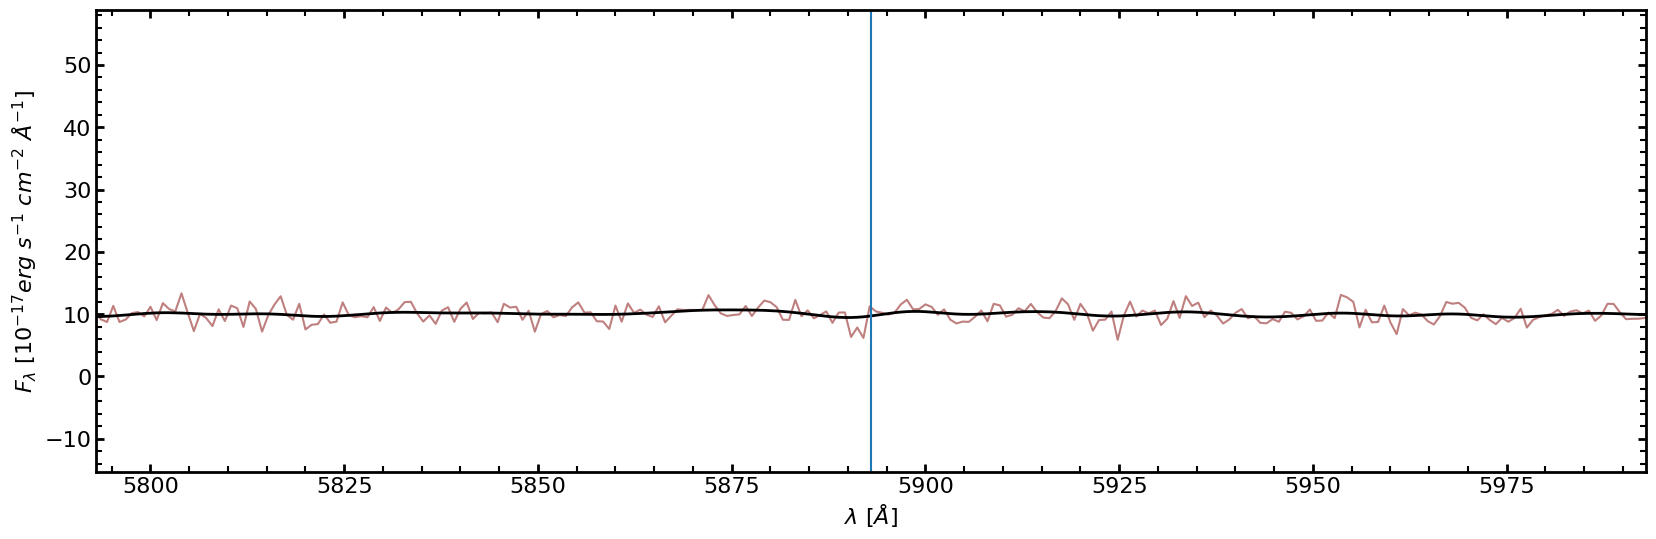

In [578]:
# Plotting this spectrum

plt.figure(figsize = (20, 6))

# Plot the original spectrum in maroon color
plt.plot(lam_primary, flam_primary, color = 'maroon', alpha = 0.5)
# Over-plotting smoothed spectra in black 
plt.plot(lam_primary, convolve(flam_primary, Gaussian1DKernel(5)), color = 'k', lw = 2.0)

plt.xlabel(r'$\lambda$ [$\AA$]')
plt.xlim(wavelength-100,wavelength+100)
plt.axvline(x=wavelength)

plt.ylabel(r'$F_{\lambda}$ [$10^{-17} erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$]')
plt.show()

In [579]:
x,y = lam_primary, flam_primary

NEW MAR2026 KS IS  100
The wrong flux error was  1.1131169918617494
The corrected flux error now is  1.0650122860534748


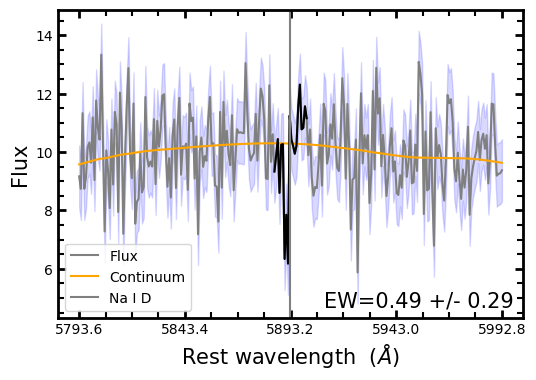


EW= 0.49  +/-  0.2903486099144827

Node separation =  85.1282051280146  Angstrom
SNR of the line is  1.6995929866799897


In [580]:
import os, sys

sys.path.append(os.path.abspath(".."))


import functions

ew,ew_unc,foo=functions.EW_voronoi_bins(np.array([y]),x,na_rest,v=400,KS=100,plots=True)#

# comparing to Dust maps

In [581]:
from dustmaps.config import config
import dustmaps.sfd
dustmaps.sfd.fetch()

Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.
Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.


In [582]:
from __future__ import print_function
from astropy.coordinates import SkyCoord
from dustmaps.sfd import SFDQuery
import astropy.units as u


coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')

sfd = SFDQuery()
ebv = sfd(coords)

print(f"E(B-V) = {ebv:.3f} mag")


"""coords = SkyCoord('12h30m25.3s', '15d15m58.1s', frame='icrs')
sfd = SFDQuery()
ebv = sfd(coords)

print('E(B-V) = {:.3f} mag'.format(ebv))""";

E(B-V) = 0.020 mag


In [583]:
len(tsel)

347

# same as above but looped for multiple galaxies

NEW MAR2026 KS IS  100
The wrong flux error was  1.1392461877978182
The corrected flux error now is  0.8854835667315465


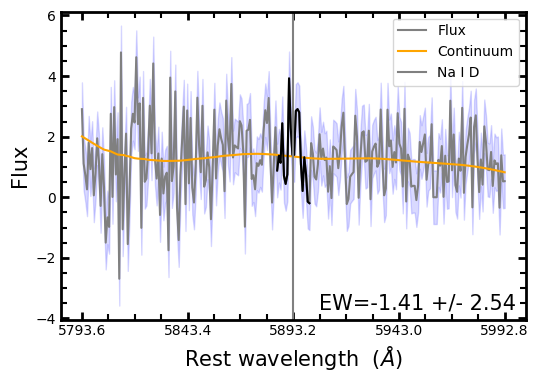


EW= -1.41  +/-  2.5386746811273784

Node separation =  88.9285714283724  Angstrom
SNR of the line is  -0.5571909218864792
E(B-V) = 0.042 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.0588880081251024
The corrected flux error now is  0.5709580413256584


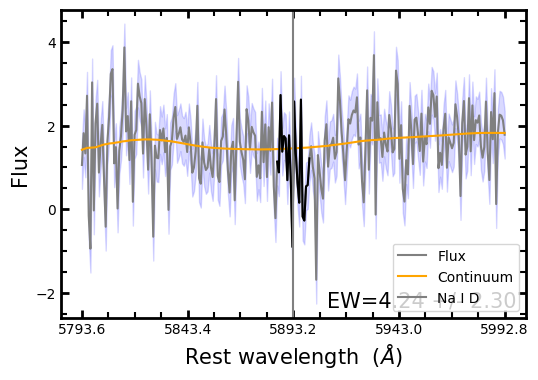


EW= 4.24  +/-  2.2963023561742855

Node separation =  91.79723502283602  Angstrom
SNR of the line is  1.8443026192777185
E(B-V) = 0.030 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.4249912807553367
The corrected flux error now is  0.9888531130188657


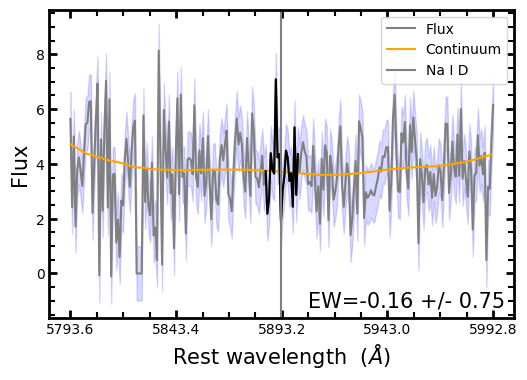


EW= -0.16  +/-  0.7491309087833914

Node separation =  91.009174311722  Angstrom
SNR of the line is  -0.21190466320412676
E(B-V) = 0.017 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.15035484976705
The corrected flux error now is  0.7505675975621547


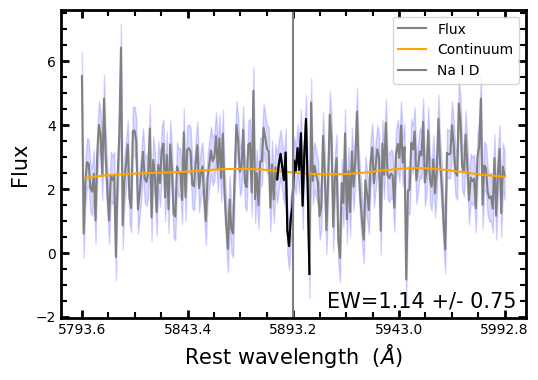


EW= 1.14  +/-  0.753766816727317

Node separation =  90.64220183465771  Angstrom
SNR of the line is  1.5148146263489723
E(B-V) = 0.015 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.3203572460097315
The corrected flux error now is  0.9129693094941612


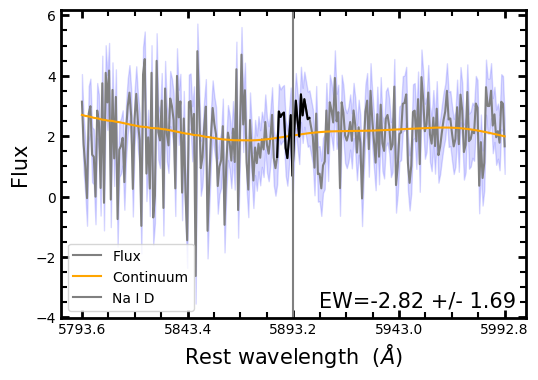


EW= -2.82  +/-  1.6904295693486093

Node separation =  87.36842105243603  Angstrom
SNR of the line is  -1.669874576619731
E(B-V) = 0.009 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.2518060339533903
The corrected flux error now is  0.6400646655084556


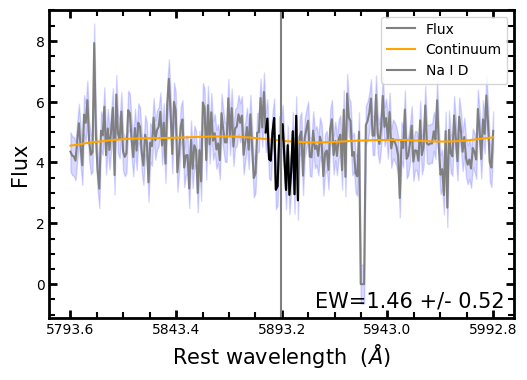


EW= 1.46  +/-  0.5229663531403012

Node separation =  87.7533039645613  Angstrom
SNR of the line is  2.7917839430964726
E(B-V) = 0.036 mag
NEW MAR2026 KS IS  100
The wrong flux error was  2.512892108399149
The corrected flux error now is  10.07667394203747


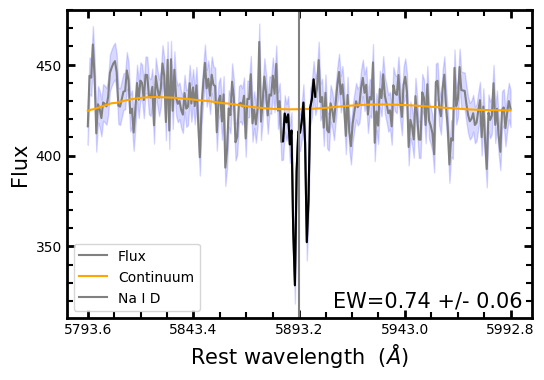


EW= 0.74  +/-  0.062212939908853876

Node separation =  88.9285714283724  Angstrom
SNR of the line is  11.943867177551356
E(B-V) = 0.026 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1579462623022756
The corrected flux error now is  0.7906704015415973


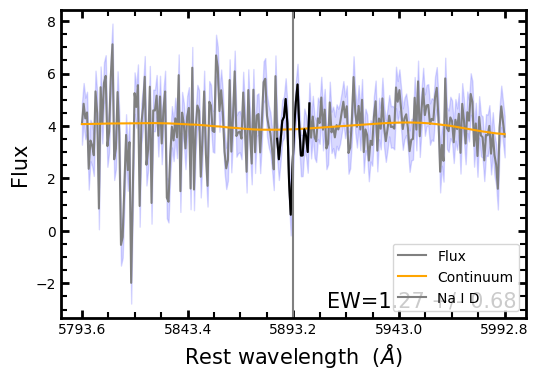


EW= 1.27  +/-  0.6843147958928739

Node separation =  92.6511627904903  Angstrom
SNR of the line is  1.8489344712956954
E(B-V) = 0.037 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1036891343072137
The corrected flux error now is  0.5890768835457569


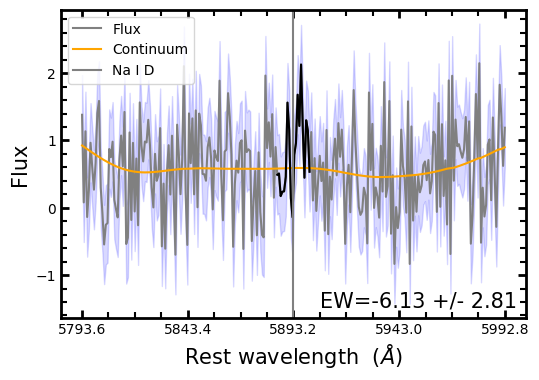


EW= -6.13  +/-  2.8100055919772813

Node separation =  83.69747899140931  Angstrom
SNR of the line is  -2.1812418030033665
E(B-V) = 0.070 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.2843454985574279
The corrected flux error now is  0.9293209728477487


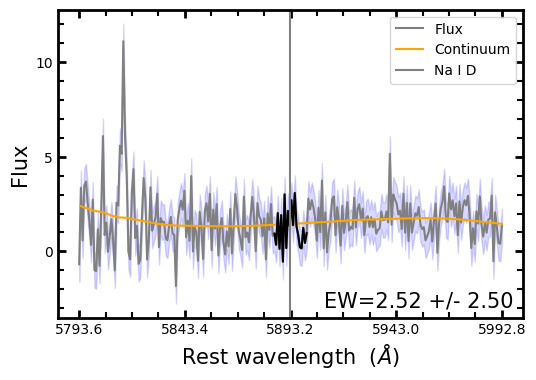


EW= 2.52  +/-  2.5010385662502874

Node separation =  86.63755458495808  Angstrom
SNR of the line is  1.0080087170711851
E(B-V) = 0.019 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1131169918617494
The corrected flux error now is  1.0650122860534748


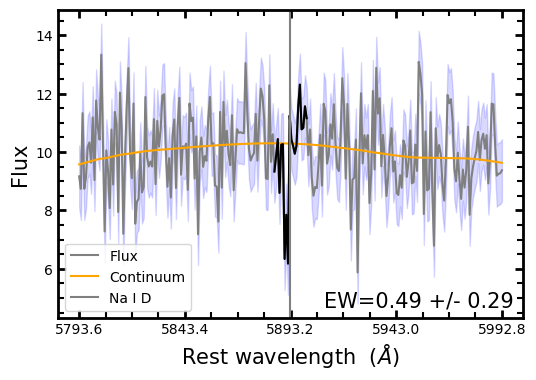


EW= 0.49  +/-  0.2903486099144827

Node separation =  85.1282051280146  Angstrom
SNR of the line is  1.6995929866799897
E(B-V) = 0.020 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.5408011962665347
The corrected flux error now is  0.8627047144958806


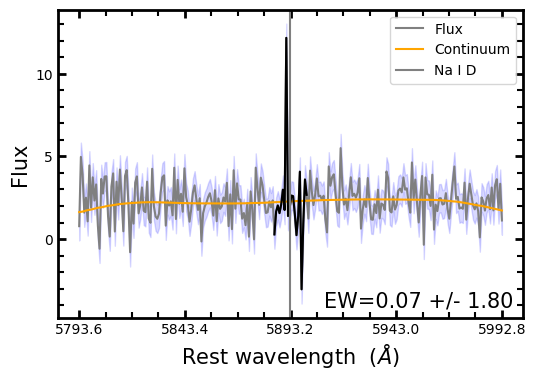


EW= 0.07  +/-  1.7994807822075436

Node separation =  90.54545454525189  Angstrom
SNR of the line is  0.040536716055361605
E(B-V) = 0.024 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.0798054901902294
The corrected flux error now is  1.1017330620724115


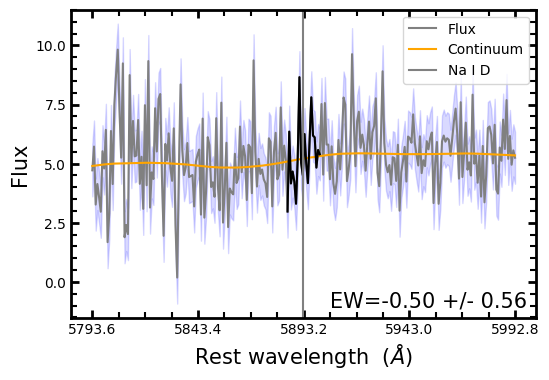


EW= -0.50  +/-  0.5599914212155197

Node separation =  88.9285714283724  Angstrom
SNR of the line is  -0.89574086826634
E(B-V) = 0.058 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.0810840892291742
The corrected flux error now is  0.6139941596515263


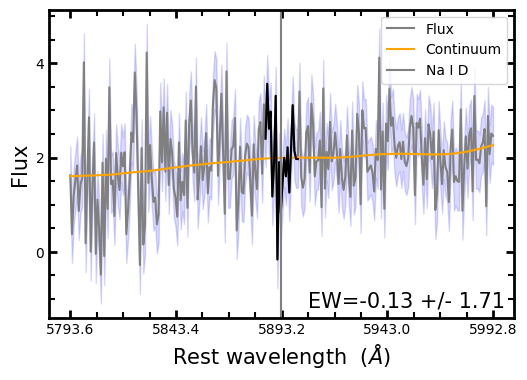


EW= -0.13  +/-  1.7107217354259272

Node separation =  88.9285714283724  Angstrom
SNR of the line is  -0.07536181937332155
E(B-V) = 0.029 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.4141005943863887
The corrected flux error now is  0.8406166877593912


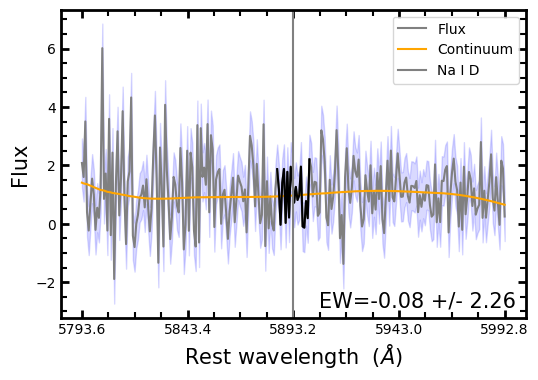


EW= -0.08  +/-  2.258545438950368

Node separation =  86.98689956312408  Angstrom
SNR of the line is  -0.03530877751656432
E(B-V) = 0.014 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.3234246719451
The corrected flux error now is  1.0175456641578369


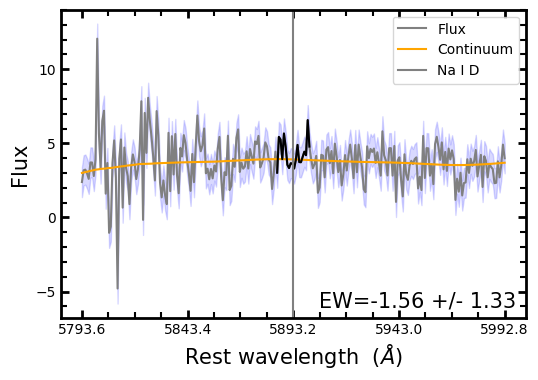


EW= -1.56  +/-  1.332064188286113

Node separation =  88.14159292015671  Angstrom
SNR of the line is  -1.1719574969789577
E(B-V) = 0.011 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.2027078512056792
The corrected flux error now is  0.9010166055794866


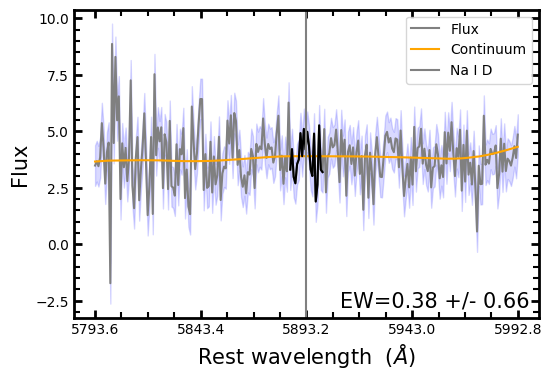


EW= 0.38  +/-  0.6572059280048904

Node separation =  86.98689956312408  Angstrom
SNR of the line is  0.5765169716317274
E(B-V) = 0.027 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.5224754872323185
The corrected flux error now is  0.7095384229220479


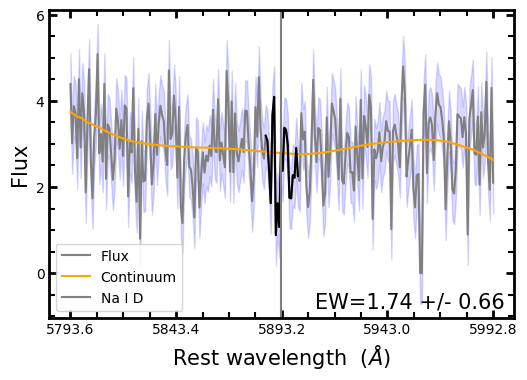


EW= 1.74  +/-  0.6577505755675804

Node separation =  86.23376623357323  Angstrom
SNR of the line is  2.6478122331487093
E(B-V) = 0.051 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.39462076952359
The corrected flux error now is  0.9075802995765131


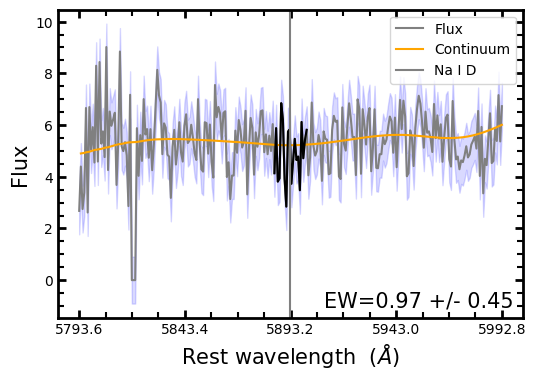


EW= 0.97  +/-  0.45482472485326536

Node separation =  85.15021459208324  Angstrom
SNR of the line is  2.127489971184933
E(B-V) = 0.009 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.2506090860653418
The corrected flux error now is  0.8215226573561555


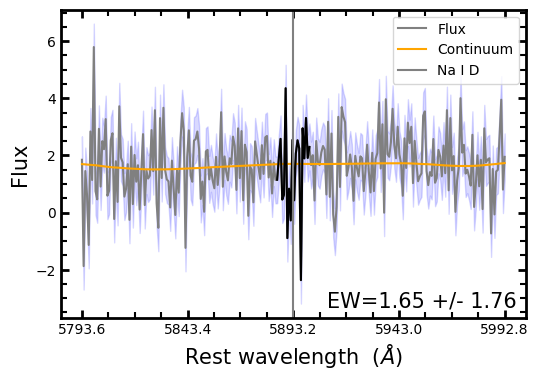


EW= 1.65  +/-  1.7560138018099138

Node separation =  90.54545454525189  Angstrom
SNR of the line is  0.9398807317870811
E(B-V) = 0.030 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.2089147837704783
The corrected flux error now is  0.903525687595903


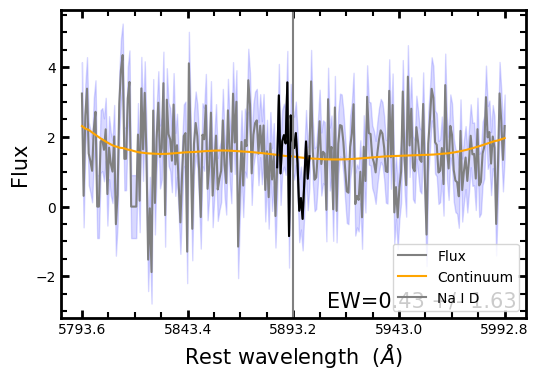


EW= 0.43  +/-  1.6250890445335713

Node separation =  88.53333333313519  Angstrom
SNR of the line is  0.26197180443854284
E(B-V) = 0.030 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.122263813282606
The corrected flux error now is  0.7394893102184125


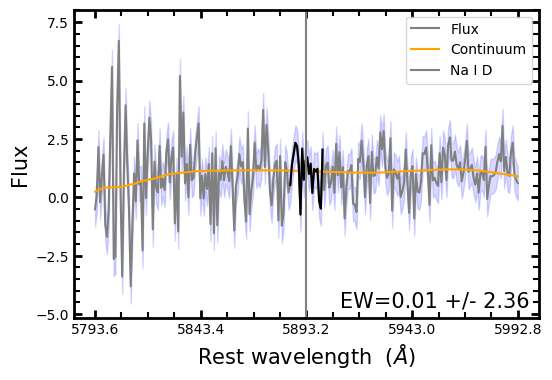


EW= 0.01  +/-  2.3580860385227567

Node separation =  96.23188405775564  Angstrom
SNR of the line is  0.004896060821738258
E(B-V) = 0.030 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1622403858533195
The corrected flux error now is  0.6530251079563836


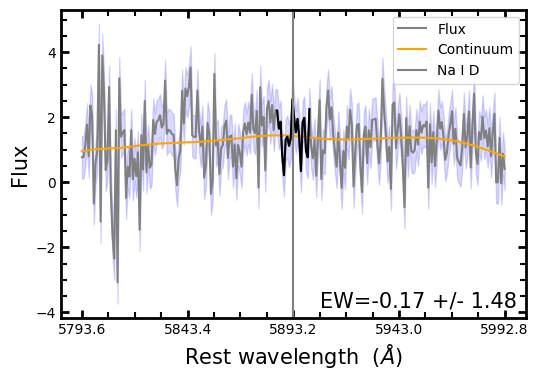


EW= -0.17  +/-  1.480088002711834

Node separation =  89.72972972952891  Angstrom
SNR of the line is  -0.11161122830254169
E(B-V) = 0.056 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1809651598679667
The corrected flux error now is  0.8535097966011841


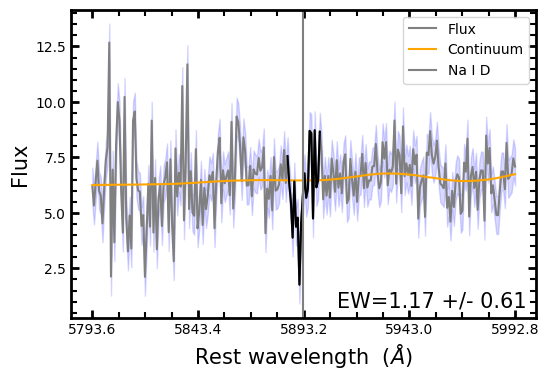


EW= 1.17  +/-  0.6097990746747908

Node separation =  98.6138613859179  Angstrom
SNR of the line is  1.9183041458400367
E(B-V) = 0.031 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.190889422065863
The corrected flux error now is  0.6084013335883838


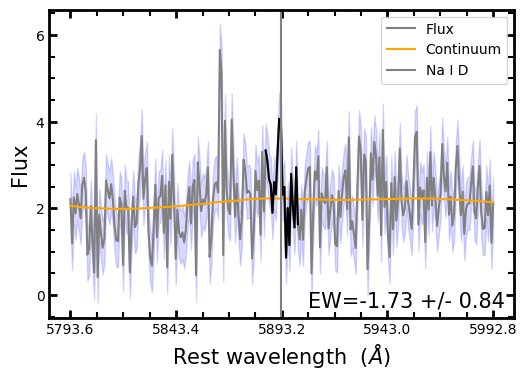


EW= -1.73  +/-  0.8444433745672928

Node separation =  88.53333333313519  Angstrom
SNR of the line is  -2.0522314878913153
E(B-V) = 0.042 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.0724519141367848
The corrected flux error now is  0.5595645239986407


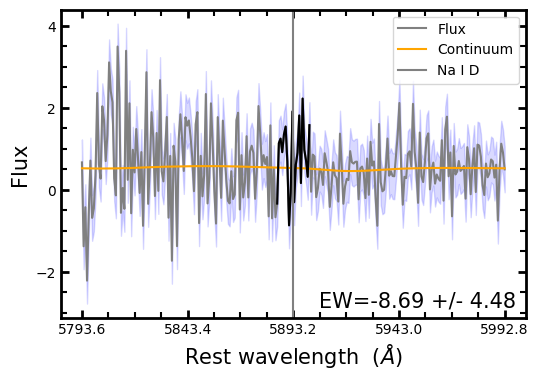


EW= -8.69  +/-  4.480565773161219

Node separation =  95.76923076901642  Angstrom
SNR of the line is  -1.9385998969207303
E(B-V) = 0.053 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1574009581618783
The corrected flux error now is  0.5950723524009389


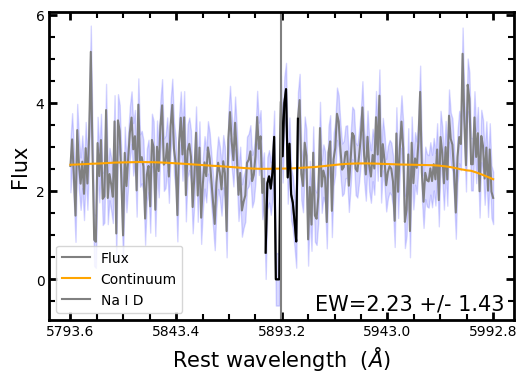


EW= 2.23  +/-  1.4332992223055685

Node separation =  90.13574660613311  Angstrom
SNR of the line is  1.5578988844952382
E(B-V) = 0.030 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1534037397232648
The corrected flux error now is  1.0900388650159445


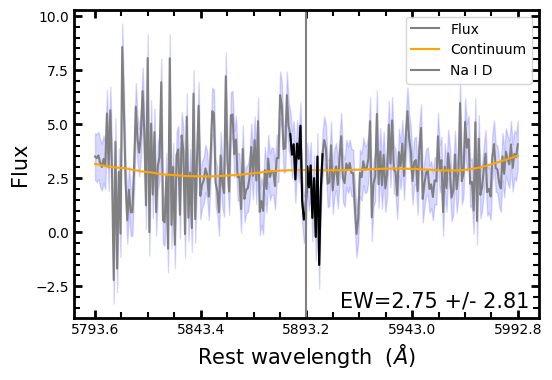


EW= 2.75  +/-  2.808106674165527

Node separation =  93.08411214932437  Angstrom
SNR of the line is  0.9800188550774572
E(B-V) = 0.048 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.042556726936355
The corrected flux error now is  0.730990341021405


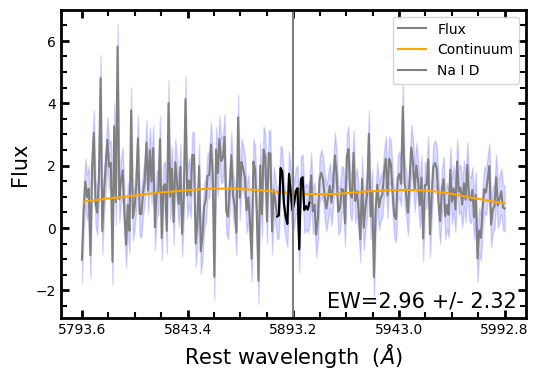


EW= 2.96  +/-  2.319278228018777

Node separation =  88.57142857122946  Angstrom
SNR of the line is  1.276555378354778
E(B-V) = 0.020 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1943680490240407
The corrected flux error now is  2.3289779853418637


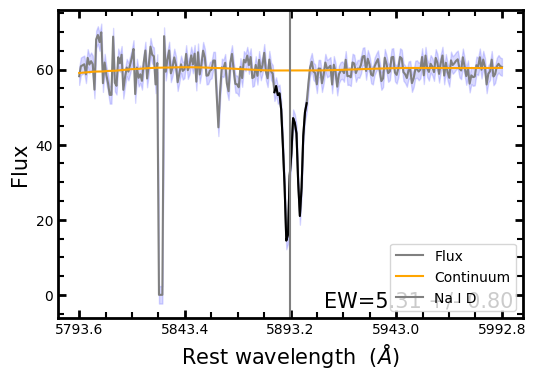


EW= 5.31  +/-  0.8047896368453897

Node separation =  93.52112676035406  Angstrom
SNR of the line is  6.593066938331887
E(B-V) = 0.068 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1506391545528007
The corrected flux error now is  0.7849964509348034


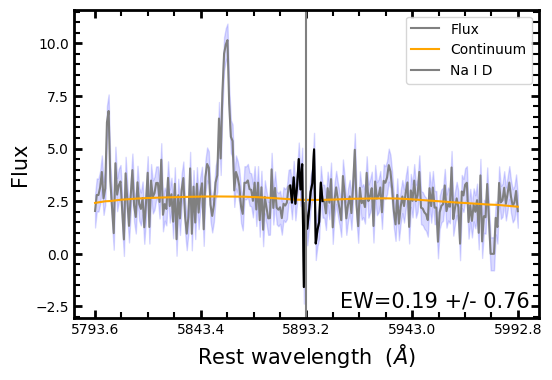


EW= 0.19  +/-  0.7620434909644243

Node separation =  88.53333333313519  Angstrom
SNR of the line is  0.24536007231183957
E(B-V) = 0.031 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.1108482162980786
The corrected flux error now is  0.8383349869235048


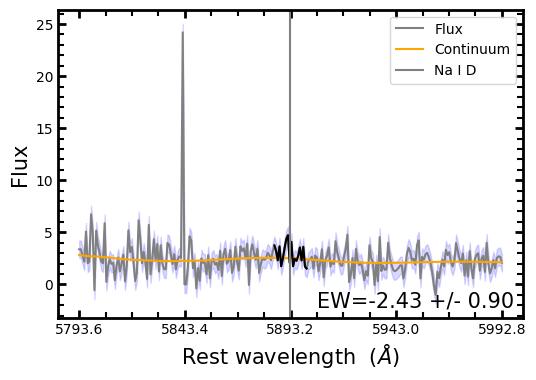


EW= -2.43  +/-  0.9030692980818198

Node separation =  92.6511627904903  Angstrom
SNR of the line is  -2.68612803266097
E(B-V) = 0.011 mag
NEW MAR2026 KS IS  100
The wrong flux error was  1.0588931816609346
The corrected flux error now is  0.3791409911835441


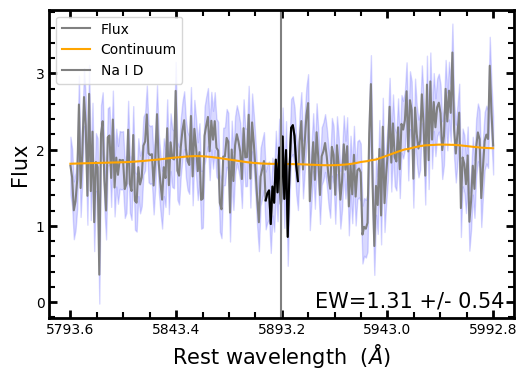


EW= 1.31  +/-  0.5356927554904585

Node separation =  84.76595744661878  Angstrom
SNR of the line is  2.437289773443531
E(B-V) = 0.047 mag


/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


NEW MAR2026 KS IS  100


ValueError: cannot reshape array of size 0 into shape (0,newaxis)

In [584]:
import os, sys
sys.path.append(os.path.abspath(".."))
import functions
from __future__ import print_function
from astropy.coordinates import SkyCoord
from dustmaps.sfd import SFDQuery
import astropy.units as u
ebv=[]
ew=[]
ew_err=[]
ra_array=[]
dec_array=[]
# Randomly select an object

sfd = SFDQuery()

for ii in range(len(tsel)):
    
    targetid = int(tsel['targetid'].data[ii])   # SPARCL accepts only python integers
    
    # Save a table with the rows that share the same targetid as selected
    tsel_id = tsel[tsel['targetid']==tsel['targetid'][ii]]
    
    # Retrieve Spectra
    
    inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary', 'survey', 'program', 'targetid', 'redshift_warning','ra','dec']
    res = client.retrieve_by_specid(specid_list = [targetid],
                                    include = inc,
                                    dataset_list = ['DESI-DR1'])
    
    records = res.records
    
    # Select the primary spectrum
    spec_primary = np.array([records[jj].specprimary for jj in range(len(records))])
    
    primary_ii = np.where(spec_primary == True)[0][0]
    
    lam_primary = records[primary_ii].wavelength
    flam_primary = records[primary_ii].flux
    
    ras = [record['ra'] for record in records]
    ra=np.average(ras)
    
    decs = [record['dec'] for record in records]
    dec=np.average(decs)
    
    x,y = lam_primary, flam_primary
    
    
    
    ew_val,ew_unc,foo=functions.EW_voronoi_bins(np.array([y]),x,na_rest,v=400,KS=100,plots=True)#
     
    
    coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
    
    
    ebv_val = sfd(coords)
    
    print(f"E(B-V) = {ebv_val:.3f} mag")
    ebv.append(ebv_val)
    ew.append(ew_val[0])
    ew_err.append(ew_unc[0])
    ra_array.append(ra)
    dec_array.append(dec)
    


In [585]:
ew
ra_array

[np.float64(127.45064507679439),
 np.float64(20.530166008751493),
 np.float64(255.09458264230048),
 np.float64(217.4149058051595),
 np.float64(221.74563819176905),
 np.float64(226.30523202275714),
 np.float64(265.1896660574754),
 np.float64(199.4536082780573),
 np.float64(252.6779753256852),
 np.float64(140.88945664000073),
 np.float64(178.43228300263635),
 np.float64(247.84722497414734),
 np.float64(25.740400226205512),
 np.float64(134.94918937260493),
 np.float64(144.70323093362208),
 np.float64(146.76218345906344),
 np.float64(127.85493674304969),
 np.float64(155.2342269114708),
 np.float64(154.76953729418946),
 np.float64(200.4982260291397),
 np.float64(238.41652620986653),
 np.float64(187.371667537842),
 np.float64(263.54131448570655),
 np.float64(186.61831664133996),
 np.float64(146.27777938280403),
 np.float64(192.1536181746807),
 np.float64(355.9153261635775),
 np.float64(155.51014039793495),
 np.float64(170.91919082301766),
 np.float64(111.75423095746342),
 np.float64(173.6002

Text(0.5, 1.0, 'BGS datset')

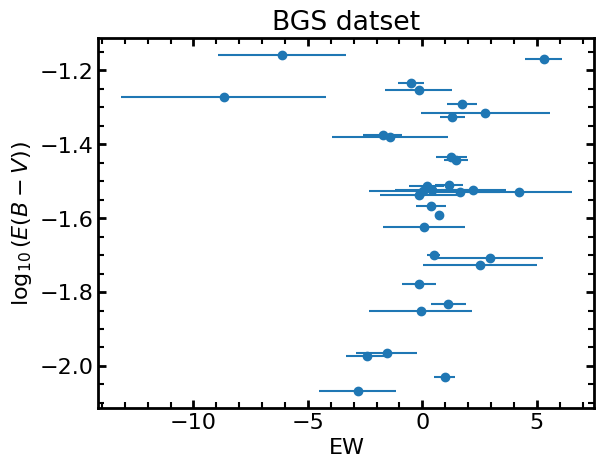

In [586]:
plt.errorbar(ew, np.log10(ebv), xerr=ew_err, fmt='o')
#plt.scatter(ew,np.log10(ebv))
plt.ylabel("$\log_{10}(E(B-V))$")
plt.xlabel("EW")
plt.title("BGS datset")

In [591]:
print(np.min(ew), np.max(ew))
print(np.min(ebv), np.max(ebv))

-8.686024345996891 5.306031946997465
0.008566268 0.06953033


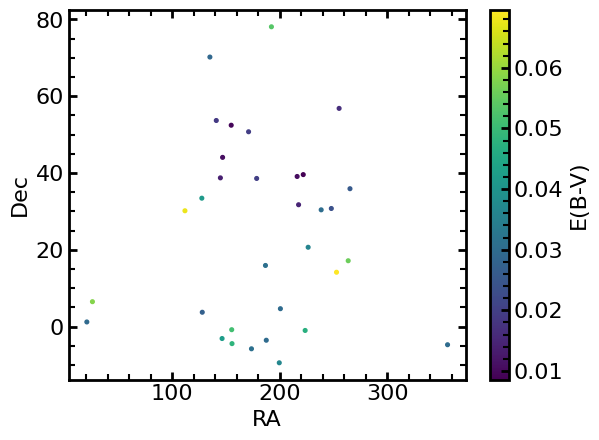

In [593]:
plt.scatter(ra_array, dec_array, c=ebv, s=7)
plt.xlabel("RA")
plt.ylabel("Dec")
plt.colorbar(label="E(B-V)")
plt.show()

#gal = SkyCoord(ra_array*u.deg, dec_array*u.deg).galactic
#plt.xlabel("RA")
#plt.ylabel("Dec")
#plt.scatter(gal.l.deg, gal.b.deg, c=ebv, s=5)
#plt.show()

In [589]:
from astropy.coordinates import SkyCoord
import astropy.units as u

c = SkyCoord(ra=ra_array*u.deg, dec=dec_array*u.deg)
gal = c.galactic

print(gal.b.deg.min(), gal.b.deg.max())

-62.38778368342872 77.38101902485518


Let us now plot all the available spectra available for this object. <br/>
In each case, the `survey`, `program`, `primary` flag and `zwarn` flag are labeled with the corresponding spectrum.

In [ ]:
# Number of spectra 
n = len(records)

fig, ax = plt.subplots(n, 1, figsize = (12,(4*n)))

for jj in range(n):
    survey = records[jj].survey
    program = records[jj].program
    spectype = records[jj].spectype
    primary_flag = records[jj].specprimary
    zwarn_flag = records[jj].redshift_warning

    lam = records[jj].wavelength
    flam = records[jj].flux
    
    # Plot the combined spectrum in maroon
    ax[jj].plot(lam, flam, color = 'maroon', alpha = 0.5)
    # Over-plotting smoothed spectra 
    ax[jj].plot(lam, convolve(flam, Gaussian1DKernel(5)), color = 'k', lw = 2.0)
    ax[jj].set(xlim = [3500, 9900], xlabel = r'$\lambda$', ylabel = r'$F_{\lambda}$')
    trans = ax[jj].get_xaxis_transform()
    ax[jj].annotate(f'{survey}, {program}', xy = (6000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'SPECTYPE : {spectype}', xy = (8000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'PRIMARY Flag : {primary_flag}', xy = (8000, 0.75), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'ZWARN Flag : {zwarn_flag}', xy = (8000, 0.65), xycoords = trans, fontsize = 16)
    
plt.tight_layout()

From the above plot, we can see that the spectrum with PRIMARY Flag = True is the one with the highest signal-to-noise ratio. The other available spectra tend to vary in quality including some of them being noisier compared to the "best" spectrum.
Let's print the table of values of their quality flags including ZWARN and COADD_FIBERSTATUS to see if any have flagged issues.  **Note**: in some cases if no valid data are available, the spectrum is blank with `zwarn > 0`.

**Notes:**
- `zwarn` contains possible redshift fitting warning or errors ([list of bit definitions](https://desidatamodel.readthedocs.io/en/latest/bitmasks.html#zwarn-bit-definitions)).
- `coadd_fiberstatus` contains [information about the fiber conditions](https://desidatamodel.readthedocs.io/en/latest/bitmasks.html#spectroscopic-reduction-masks) during the observations.
- When all spectra have `zwarn = 0`, the best one is chosen by the value of `tsnr2_lrg`, which is a proxy for the achieved depth (signal-to-noise) of the spectrum.

If you got back to examine the spectra above, you might be able to see that the best looking ones (with less noise) have higher values of `tsnr2_lrg`. For instance, dark-time spectra achieve higher signal than bright-time ones.

<a class="anchor" id="multiple_spectra"></a>
## Objects with multiple coadded spectra

In [ ]:
# Write a query to select all main objects with N>1 spectrum (detailed info below)
q_multi = """
        SELECT targetid, survey, program, desi_target, 
               z, zwarn, coadd_fiberstatus, spectype, 
               CAST(main_primary AS int), main_nspec
        FROM desi_dr1.zpix
        WHERE (survey='main') AND (main_nspec>1)
        """

# Information about the query
# 
# Selected columns --
#   targetid, survey, program -- unique identifiers for a given spectrum
#   desi_target -- encodes main survey's desi targeting information - explained in detail below
#   z -- spectroscopic redshift of the target
#   zwarn -- encoded information regarding the redshift (zwarn = 0 is good)
#   coadd_fiberstatus -- encoded information regarding the fiber that is assigned to the target (coadd_fiberstatus = 0 is good)
#   spectype -- Spectral type of the target: STAR | GALAXY | QSO
#   main_nspec -- Number of coadded spectra that are available for a given target
#   main_primary -- Whether or not a given coadded spectra is the primary spectra. ZCAT_PRIMARY = True for the "best" spectrum.
#   CASTing this column as an INT: ZCAT_PRIMARY = 1 for the "best" spectrum.
# Constraints (WHERE statement) --
#   survey: selecting main survey only
#   main_nspec: keeping objects with more than one Main survey spectrum
#               (e.g., they were observed on both DARK and BRIGHT programs)

In [ ]:
zmulti = qc.query(sql = q_multi, fmt = 'table')

In [ ]:
print(f"The resulting table has {len(zmulti)} rows")
zmulti[0:5]

In [ ]:
is_primary = zmulti['main_primary']==1

print(f"N(rows) with MAIN_PRIMARY=True : {len(zmulti[is_primary])}")
print(f"N(rows) with MAIN_PRIMARY=False: {len(zmulti[~is_primary])}")

In [ ]:
# Check how many per program (and fraction that are "Primary" = "Best" spectrum)
programs = np.unique(zmulti['program'])
programs

for program in programs:
    is_prog = zmulti['program']==program
    is_mult = zmulti['main_nspec']>1
    N_prog = len(zmulti[is_prog])
    N_multiple = len(zmulti[is_prog&is_mult])
    N_primary = len(zmulti[is_prog&is_mult&is_primary])
    percent = np.round(N_primary/N_multiple*100, 1)

    print(f"Program={program}")
    print(f"  {N_multiple} have >1 spectrum; {N_primary} ({percent}%) are the primary")

**Note**: As expected, the dark-time spectra tend to have a higher quality than the bright-time ones so they are typically favored as the "best" primary spectrum.

**Exercise**: One could dig deeper to figure out why, in a small fraction of cases, the bright-time spectrum was chosen as the primary one. Is there something wrong with the fiber condition (`COADD_FIBERSTATUS>0`) and/or with the redshift determination (`ZWARN>0`) for the dark-time spectra in such cases?

<a class="anchor" id="ref"></a>
# References

## Papers
* DESI DR1 paper: [DESI Collaboration et al. 2025](https://ui.adsabs.harvard.edu/abs/2025arXiv250314745D/abstract) ([arXiv](https://arxiv.org/abs/2503.14745))
* DESI Target Selection pipeline paper: [Myers et al. 2023](https://ui.adsabs.harvard.edu/abs/2023AJ....165...50M/abstract)

## Useful links
* DESI Data Documentation: https://data.desi.lbl.gov/doc/
* DESI access at Astro Data Lab: https://datalab.noirlab.edu/desi/
* Information about SPARCL: https://astrosparcl.datalab.noirlab.edu/sparc/
* Datamodel information: https://desidatamodel.readthedocs.io/en/latest/
* Information about DESI bitmasks: https://desidatamodel.readthedocs.io/en/latest/bitmasks.html
* Introduction to SPARCL notebook: https://github.com/astro-datalab/notebooks-latest/blob/master/04_HowTos/SPARCL/How_to_use_SPARCL.ipynb

---